# Model training sur les données "Oily, Dry, Normal"

## Preprocessing

In [1]:
import os
from PIL import Image
import numpy as np
import cv2
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Configuration du device et des paramètres
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Travail sur : {device}")
BATCH_SIZE = 32
NUM_CLASSES = 3

# Fonction de normalisation d'Histogramme
def apply_clahe_lab(img): 
    """
    Égalisation d'histogramme adaptative (CLAHE). 
    Améliore le contraste localement pour éviter que les zones très sombres ou très claires de la peau ne perdent leurs détails.
    Idéal pour uniformiser des photos prises sous différentes lumières.
    """
    # Conversion PIL -> Numpy (OpenCV travaille en tableaux)
    img_array = np.array(img)
    
    # Passage en LAB : L (Luminance), A et B (Couleurs)
    lab = cv2.cvtColor(img_array, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    
    # Application du CLAHE sur la Luminance uniquement
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    
    # Fusion et retour en RGB
    lab = cv2.merge((l, a, b))
    final_img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    
    # Retour au format PIL pour la suite du pipeline PyTorch
    return Image.fromarray(final_img)

# Pipeline de transformation
data_transforms = {
    'train': transforms.Compose([
        transforms.Lambda(lambda x: apply_clahe_lab(x)),
        transforms.Resize(224),         # Redimensionne le petit côté à 224px
        transforms.CenterCrop(224),     # Coupe un carré central de 224x224, afin de maintenir les ratios 
        transforms.RandomHorizontalFlip(p=0.5), # Augmentation géométrique légère
        transforms.ToTensor(),          # Conversion en Tensor [0.0, 1.0]
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Normalisation Standard ImageNet 
    ]),
    'val': transforms.Compose([
        transforms.Lambda(lambda x: apply_clahe_lab(x)),
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Chargement des données 

# Définition des chemins
data_dir = "../../../data/processed/skin_images/oily-dry-normal"

# Cela va automatiquement lier les dossiers (dry, normal, oily) aux labels (0, 1, 2)
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir, 'train'), data_transforms['train']),
    'val': datasets.ImageFolder(os.path.join(data_dir, 'valid'), data_transforms['val'])
}

# Création des DataLoaders
dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True),
    'val': DataLoader(image_datasets['val'], batch_size=32, shuffle=False)
}

# Vérification
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Données chargées : {dataset_sizes}")
print(f"Classes détectées : {class_names}")

Travail sur : cpu
Données chargées : {'train': 2756, 'val': 262}
Classes détectées : ['dry', 'normal', 'oily']


## Récupérer le modèle pré-entraîné

In [2]:
import torch
import torch.nn as nn
from torchvision import models

# On charge le modèle avec les poids les plus récents (ImageNet)
weights = models.MobileNet_V2_Weights.DEFAULT
model = models.mobilenet_v2(weights=weights)

# On bloque les couches de bases pour ne pas les modifier lors des premières étapes d'entraînement
for param in model.parameters():
    param.requires_grad = False

# On adapte la couche de classification
num_classes = 3
# La structure de MobileNetV2.classifier[1] est la couche Linear de sortie
# En faisant ça, on récupère donc le nombre de neurones d'entrée de la dernière couche (1280)
in_features = model.classifier[1].in_features
# On remplace la couche de sortie par une nouvelle couche Linear (3 classes : Dry, Normal, Oily)
model.classifier[1] = nn.Linear(in_features, num_classes)

# Envoi du modèle sur le device
model = model.to(device)

print("Modèle MobileNet V2 chargé, gelé et adapté aux 3 classes")

Modèle MobileNet V2 chargé, gelé et adapté aux 3 classes


## Configurer la loss et l'optimiseur

In [3]:
from collections import Counter

# On compte les images par classe dans le dataset d'entraînement
train_labels = [sample[1] for sample in image_datasets['train'].samples]
label_counts = Counter(train_labels)

# Formule : total_samples / (nb_classes * nb_samples_dans_classe)
total_samples = len(train_labels)
weights = [total_samples / (NUM_CLASSES * label_counts[i]) for i in range(NUM_CLASSES)]
class_weights = torch.FloatTensor(weights).to(device)

print(f"Poids de classes : {dict(zip(class_names, weights))}")

Poids de classes : {'dry': 1.408997955010225, 'normal': 0.8321256038647343, 'oily': 0.9186666666666666}


**Pourquoi cette formule ?**

Si on utilisait la proportion de notre EDA ($Count/Total$), on récompenserait le modèle d'être paresseux et de ne prédire que les classes faciles. En utilisant l'inverse ($Total/Count$), on crée une discrimination positive : on sur-pénalise les erreurs sur les classes rares pour forcer le modèle à les apprendre aussi bien que les autres.

Le NUM_CLASSES est là pour normaliser les poids. Son rôle est de faire en sorte que, malgré la redistribution de l'importance entre les classes, l'erreur globale reste à une échelle raisonnable. C'est ce qui permet au modèle d'apprendre de manière stable sans que les ajustements ne soient trop violents à chaque image rare rencontrée.

In [4]:
# Définition de la loss dans laquelle on passe class_weights pour que le modèle accorde plus d'importance aux classes minoritaires
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Définition de l'optimiseur qui n'optimise que les paramètres du classifier (la tête du modèle)
optimizer = torch.optim.Adam(model.classifier[1].parameters(), lr=0.001)

print("Loss et Optimiseur configurés.")

Loss et Optimiseur configurés.


## Configurer l'entraînement

In [5]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()  # Active le Dropout (éteindre aléatoirement certains neurones) et la Batch Normalization
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Nettoyage des gradients précédents

        # Forward pass
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)

        # Backward pass (Calcul de l'erreur + mise à jour des poids)
        loss.backward()
        optimizer.step()

        # Stats
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = running_corrects.double() / len(dataloader.dataset)
    return epoch_loss, epoch_acc

## Configurer l'évaluation

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


def evaluate_epoch(model, dataloader, criterion, device):
    """
    Évaluation légère utilisée à chaque epoch.
    Retourne uniquement (loss, accuracy, f1) sans aucun affichage.
    """
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            total_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = (all_preds == all_labels).mean()
    f1       = f1_score(all_labels, all_preds, average='weighted')

    return avg_loss, accuracy, f1


def evaluate_full(model, dataloader, criterion, device, dataset_name="Validation"):
    """
    Évaluation complète post-entraînement.
    Affiche : métriques globales, rapport par classe, matrice de confusion.
    """
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            total_loss += loss.item() * inputs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = (all_preds == all_labels).mean()
    f1       = f1_score(all_labels, all_preds, average='weighted')

    # Métriques globales
    print(f"\n{'='*50}")
    print(f"  ÉVALUATION FINALE — {dataset_name.upper()}")
    print(f"{'='*50}")
    print(f"  Loss     : {avg_loss:.4f}")
    print(f"  Accuracy : {accuracy:.4f}")
    print(f"  F1 (weighted) : {f1:.4f}")
    print(f"{'='*50}\n")

    # Rapport détaillé par classe
    print("Rapport détaillé par classe :")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Matrice de Confusion
    cm = confusion_matrix(all_labels, all_preds)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax, colorbar=False)
    plt.title(f'Matrice de Confusion — {dataset_name}')
    plt.tight_layout()
    plt.show()

    return avg_loss, accuracy, f1

## Boucle d'entraînement + évaluation

Lancement de l'entraînement sur cpu...
Epoch  1/10 | Train — Loss: 1.0768  Acc: 0.4020  F1: 0.5025 | Val   — Loss: 1.0698  Acc: 0.4084  F1: 0.3998
Epoch  2/10 | Train — Loss: 1.0125  Acc: 0.4931  F1: 0.5406 | Val   — Loss: 1.0738  Acc: 0.3702  F1: 0.3668
Epoch  3/10 | Train — Loss: 0.9642  Acc: 0.5483  F1: 0.5808 | Val   — Loss: 1.0670  Acc: 0.4351  F1: 0.4233
Epoch  4/10 | Train — Loss: 0.9365  Acc: 0.5653  F1: 0.6431 | Val   — Loss: 1.0587  Acc: 0.4237  F1: 0.4243
Epoch  5/10 | Train — Loss: 0.9107  Acc: 0.5918  F1: 0.6270 | Val   — Loss: 1.0931  Acc: 0.4008  F1: 0.3992
Epoch  6/10 | Train — Loss: 0.8917  Acc: 0.5911  F1: 0.6550 | Val   — Loss: 1.0905  Acc: 0.4237  F1: 0.4250
Epoch  7/10 | Train — Loss: 0.8786  Acc: 0.6078  F1: 0.6774 | Val   — Loss: 1.0892  Acc: 0.4427  F1: 0.4330
Epoch  8/10 | Train — Loss: 0.8732  Acc: 0.6070  F1: 0.7003 | Val   — Loss: 1.0934  Acc: 0.4351  F1: 0.4349
Epoch  9/10 | Train — Loss: 0.8507  Acc: 0.6306  F1: 0.7181 | Val   — Loss: 1.0905  Acc: 0.4466  

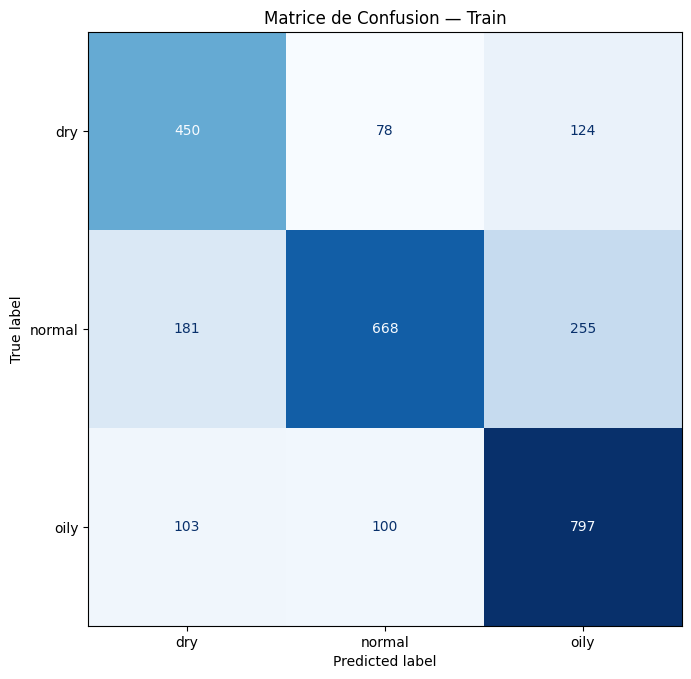


  ÉVALUATION FINALE — VALIDATION
  Loss     : 1.1055
  Accuracy : 0.4504
  F1 (weighted) : 0.4524

Rapport détaillé par classe :
              precision    recall  f1-score   support

         dry       0.37      0.38      0.38        71
      normal       0.55      0.49      0.51       111
        oily       0.41      0.46      0.44        80

    accuracy                           0.45       262
   macro avg       0.44      0.44      0.44       262
weighted avg       0.46      0.45      0.45       262



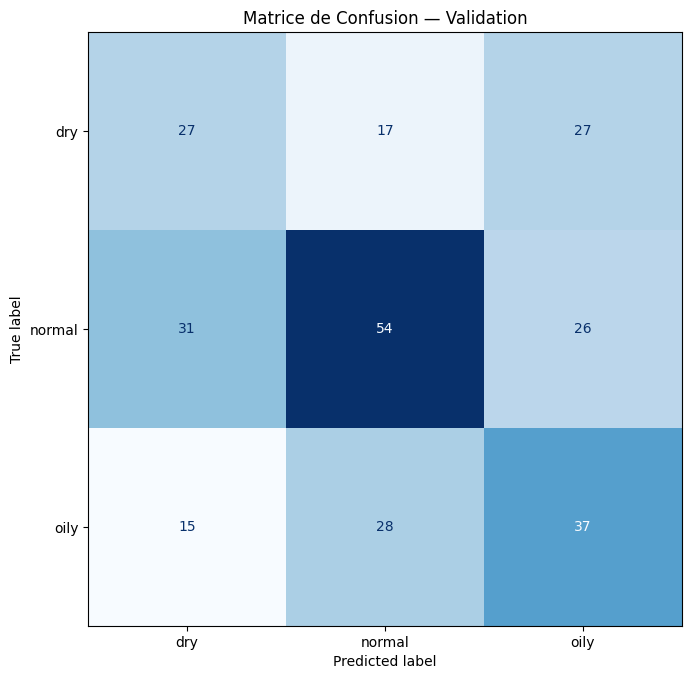

(1.1054696454346635, np.float64(0.45038167938931295), 0.4524207774712939)

In [7]:
import time
import copy

# ── Configuration de l'expérience ────────────────────────────────────────────
num_epochs     = 10
best_model_wts = copy.deepcopy(model.state_dict())
best_val_acc   = 0.0

# Historique : loss, accuracy et F1 pour train ET val
history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss':   [], 'val_acc':   [], 'val_f1':   []
}

print(f"Lancement de l'entraînement sur {device}...")
since = time.time()

# ── Boucle principale ────────────────────────────────────────────────────────
for epoch in range(num_epochs):

    # Phase TRAIN
    train_loss, train_acc = train_one_epoch(
        model, dataloaders['train'], criterion, optimizer, device
    )

    # Phase EVAL train (légère — pas de plots)
    _, _, train_f1 = evaluate_epoch(
        model, dataloaders['train'], criterion, device
    )

    # Phase EVAL validation (légère — pas de plots)
    val_loss, val_acc, val_f1 = evaluate_epoch(
        model, dataloaders['val'], criterion, device
    )

    # Stockage dans l'historique
    history['train_loss'].append(train_loss)
    history['train_acc'].append(float(train_acc))
    history['train_f1'].append(float(train_f1))
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    # Sauvegarde du meilleur modèle (val accuracy)
    if val_acc > best_val_acc:
        best_val_acc   = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch+1:>2}/{num_epochs} | "
        f"Train — Loss: {train_loss:.4f}  Acc: {float(train_acc):.4f}  F1: {train_f1:.4f} | "
        f"Val   — Loss: {val_loss:.4f}  Acc: {val_acc:.4f}  F1: {val_f1:.4f}"
    )

# ── Bilan de l'entraînement ──────────────────────────────────────────────────
time_elapsed = time.time() - since
print(f'\nEntraînement terminé en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
print(f'Meilleure Accuracy en Validation : {best_val_acc:.4f}')

# ── Chargement des meilleurs poids ────────────────────────────────────────────
model.load_state_dict(best_model_wts)

# ── Évaluation finale complète : TRAIN puis VALIDATION ───────────────────────
evaluate_full(model, dataloaders['train'], criterion, device, "Train")
evaluate_full(model, dataloaders['val'],   criterion, device, "Validation")

**Expériences:**
- N°1 : Baseline MobileNetV2 (Freezed) sur 10 epochs (LR: 0.001, Batch: 32) avec prétraitement CLAHE et Weighted CrossEntropy pour équilibrer les classes.

## Courbes d'apprentissage

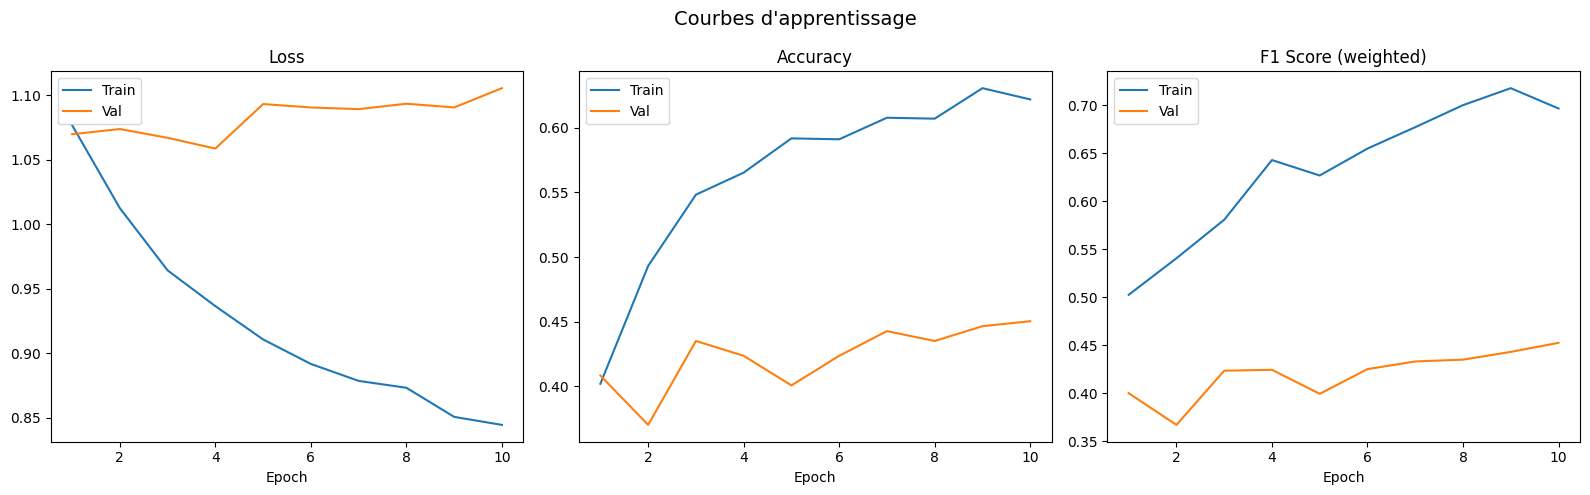

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
epochs_range = range(1, num_epochs + 1)

# Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Accuracy
axes[1].plot(epochs_range, history['train_acc'], label='Train')
axes[1].plot(epochs_range, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

# F1
axes[2].plot(epochs_range, history['train_f1'], label='Train')
axes[2].plot(epochs_range, history['val_f1'],   label='Val')
axes[2].set_title('F1 Score (weighted)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle("Courbes d'apprentissage", fontsize=14)
plt.tight_layout()
plt.show()
